In [1]:
import math
import numpy as np
import gymnasium as gym

from itertools import count
from importnb import Notebook

with Notebook():
    from LabLatencyModel import LatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents

In [ ]:
class EnvWrapper(gym.Env):
    """
    Simple wrapper that delegates all calls to an inner env.
    Subclass this to create your own wrappers.
    """

    def __init__(
        self, 
        n: int,
        n_layers: int,
        lam: float,
        theta: float,
        users_env: None,
        cache_env: None,
        latency_model: None 
    ):
        super().__init__()

        self.step_count = 0

        self.n = n  # number of tiles per row/column
        self.n_layers = n_layers  # number of layers (base + enhancement)
        
        self.gain_if_prefetched = 1.0
        self.loss_if_not_prefetched = -1.0

        self.theta = theta
        self.lam = lam

        self.users_env = users_env
        self.cache_env = cache_env
        self.latency_model = latency_model

    def sample_action(self):
        n_users = self.users_env.n_users
        
        tiles = np.zeros(self.n * self.n, dtype=int)
        c = self.n // 2
        if self.n % 2 == 1:
            center_idx = c * self.n + c
            tiles[center_idx] = 1
        else:
            centers = [(c-1, c-1), (c-1, c), (c, c-1), (c, c)]
            for y, x in centers:
                tiles[y * self.n + x] = 1

        return [
            {
                'user': u,
                'video': np.random.randint(0, self.users_env.n_videos),
                'gop': np.random.randint(0, self.users_env.n_gops),
                'tiles': tiles.tolist()
            } for u in range(n_users)
        ]

    def step(self, action):
        reward = 0.0
        info = {}

        ### STEP 1: prefetching segments in the cache based on action taken ###
        cache_bitmap = self.cache_env.process_cache_prefetching(action)

        ### STEP 2: Generate user requests ###
        reqs = self.users_env.step(cache_bitmap)
        info['users_requests'] = reqs
        
        ### STEP 2.1: Compute Content Popularity Distribution ###
        self.cache_env.update_content_popularity(reqs)
        info['content_popularity'] = self.cache_env.get_content_popularity()

        # print(f"Step {self.step_count}: Generated {len(reqs)} user requests.")
        # for req in reqs:
        #     print(
        #         f"  User {req['u']} requested video {req['video']} GOP {req['gop']} with {len(req['tiles'])} tiles."
        #     )

        ### STEP 3: compute latencies for each request ###
        total_latency = 0.0
        for req in reqs:
            p = req["p"]
            u = req["u"]
            tiles = req["tiles"]
            
            req_latency, tile_latencies = self.latency_model.total_request_latency(
                p,
                u,
                tiles,
                len(reqs)
            )

            total_latency += req_latency
            # print(
            #     f"User {u}, DU {p}, total latency: {req_latency:.4f}s, tiles requested: {len(tiles)}, tiles received: {len(tile_latencies)}"
            # )
        
        ### STEP 4: Calculate metrics: cache hits and misses, and reward ###
        cache_hits = 0
        cache_misses = 0
        for req in reqs:
            tiles = req['tiles']
            for tile in tiles:
                hit = tile['events']['alpha_p_u']
                if hit >= 1:
                    cache_hits += 1
                else:
                    cache_misses += 1

        info['cache_hits'] = int(cache_hits)
        info['cache_misses'] = int(cache_misses)
        info['cache_current_capacity'] = self.cache_env.get_current_capacity()
        info['cache_total_capacity'] = self.cache_env.max_capacity
        info['cache_utilization'] = info['cache_current_capacity'] / info['cache_total_capacity']
        info['cache_num_items'] = self.cache_env.policy.get_stats().get('num_items', 0)

        # compute reward for this video's action and add
        total_requests = sum(len(req.get('tiles', [])) for req in reqs)
        
        # Compute current_p: probability for each (vid, tile_idx) based on requests
        tile_counts = {}
        for req in reqs:
            vid = req["video"]
            tiles = req["tiles"]
            for tile in tiles:
                key = (vid, tile['layer'], tile['tile'])
                tile_counts[key] = tile_counts.get(key, 0) + 1

        # Normalize by total_requests to get probabilities
        current_p = {
            key: count / total_requests
            for key, count in tile_counts.items()
        }
    
        reward += self.compute_expected_cpt_reward(
            current_p=current_p,
            requests=reqs
        )

        done = (self.users_env.users_done >= self.users_env.n_users)

        self.step_count += 1
        return {}, reward, done, info

    def compute_expected_cpt_reward(
        self, 
        current_p, 
        requests
    ) -> float:
        expected_reward = 0.0
        requested_tile_keys = set()
        for request in requests:
            vid = request['video']
            tiles = request['tiles']

            for tile in tiles:
                layer = tile['layer']
                tile_idx = tile['tile']
                tile_key = (vid, layer, tile_idx)
                
                p = float(current_p.get(tile_key, 0.0))
                w = self.prelec_w(p, theta=self.theta)

                prefetch = tile['events']['alpha_p_u']
                if prefetch == 1:
                    expected_outcome = self.gain_if_prefetched
                    requested_tile_keys.add(tile_key)
                else:
                    expected_outcome = self.loss_if_not_prefetched
                
                v = self.cpt_value(expected_outcome, lam=self.lam)
                expected_reward += w * v

        return float(expected_reward)

    def prelec_w(self, p: float, theta: float = 0.65) -> float:
        if p <= 0.0: return 0.0
        if p >= 1.0: return 1.0
        return math.exp(-((-math.log(p)) ** theta))

    def cpt_value(
        self,
        x: float, 
        lam: float = 1.5
    ) -> float:
        if x >= 0:
            return x
        else:
            return -lam * (-x)

    def reset(self, **kwargs):
        _, info_users = self.users_env.reset(**kwargs)
        _, info_cache = self.cache_env.reset(**kwargs)
        # self.latency_model.reset(**kwargs)
        
        info = {
            **info_users, 
            **info_cache
        }

        return None, info 

In [3]:
def getTiles(step, user, users_viewport_tiles, n) -> np.ndarray:
    mask = np.zeros(n * n, dtype=int)    
    for tx, ty in users_viewport_tiles[user][step]:
        if 0 <= tx < n and 0 <= ty < n:
            mask[ty * n + tx] = 1
    
    return mask

In [4]:
if __name__ == "__main__":
    n_episodes = 100
    n_users = 100
    step_size = 5.0
    alpha = 1.0
    n_gops = 60
    n_layers = 2
    n = 4
    max_capacity = 5000e6  # 5000 MB
    n_videos = 1000

    #### CPT parameters ####
    lam = 3.7183
    theta = 0.5

    users_env = UserTileRequestEvents(
        n_users=n_users,
        step_size=step_size,
        n_videos=n_videos,
        n_gops=n_gops,
        n_layers=n_layers,
        n_tiles=n*n,
        n=n,
        alpha=alpha,
        users_viewport_tiles=None,
        requested_videos=None
    )

    cache_env = CacheEngineEnv(
        n_tiles=n*n,
        n_videos=n_videos,
        cache_capacity=max_capacity
    )

    # Create latency model (replace numbers with your real config)
    P = 1; max_U = n_users
    lat_model = LatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    env = EnvWrapper(
        n=n,
        n_layers=n_layers,
        users_env=users_env, 
        cache_env=cache_env, 
        latency_model=lat_model,
        lam=lam,
        theta=theta
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {n_videos}x{n_layers}x{n*n}\n"
        f"==============================\n"
    )

    _, info = env.reset()
    viewport_tiles = info['viewport_tiles']
    requested_videos = info['requested_videos']

    done = False
    results = []
    total_reward = 0.0

    for step in count():
        actions = [
            {
                'user': user,
                'video': requested_videos[user],
                'tiles': getTiles(step % n_gops, user, viewport_tiles, n),
                'gop': step % n_gops
            } for user in range(n_users)
        ]

        obs, reward, done, info = env.step(actions)

        total_reward += float(reward)

        results.append({
            "step": step,
            "total_reward": total_reward,
            "cache_hits": info["cache_hits"],
            "cache_misses": info["cache_misses"],
            "info": info
        })

        print(
            f"Step {step} - "
            f"Reward: {reward:.4f} - "
            f"Total Reward: {total_reward:.4f} - "
            f"Cache Hits: {info['cache_hits']} - "
            f"Cache Misses: {info['cache_misses']}"
        )

        print(
            f"Cache Utilization: {info['cache_utilization']:.2%} - "
            f"Items in Cache: {info['cache_num_items']} - "
            f"Final Capacity: {info['cache_current_capacity']/1e6:.2f}/{info['cache_total_capacity']/1e6:.1f} MB"
        )
        
        if done: 
            break

Experiment ===================
Total users: 100
Cache capacity: 5000000000.0MB
Video matrix: 1000x2x16

Step 0 - Reward: 0.0000 - Total Reward: 0.0000 - Cache Hits: 0 - Cache Misses: 0
Cache Utilization: 7.05% - Items in Cache: 1194 - Final Capacity: 352.38/5000.0 MB
Step 1 - Reward: 0.0000 - Total Reward: 0.0000 - Cache Hits: 0 - Cache Misses: 0
Cache Utilization: 14.45% - Items in Cache: 2407 - Final Capacity: 722.56/5000.0 MB
Step 2 - Reward: 3.5428 - Total Reward: 3.5428 - Cache Hits: 20 - Cache Misses: 0
Cache Utilization: 22.23% - Items in Cache: 3640 - Final Capacity: 1111.50/5000.0 MB
Step 3 - Reward: 3.5428 - Total Reward: 7.0856 - Cache Hits: 20 - Cache Misses: 0
Cache Utilization: 30.06% - Items in Cache: 4876 - Final Capacity: 1503.25/5000.0 MB
Step 4 - Reward: 3.5428 - Total Reward: 10.6284 - Cache Hits: 20 - Cache Misses: 0
Cache Utilization: 38.01% - Items in Cache: 6118 - Final Capacity: 1900.62/5000.0 MB
Step 5 - Reward: 5.8605 - Total Reward: 16.4889 - Cache Hits: 40 

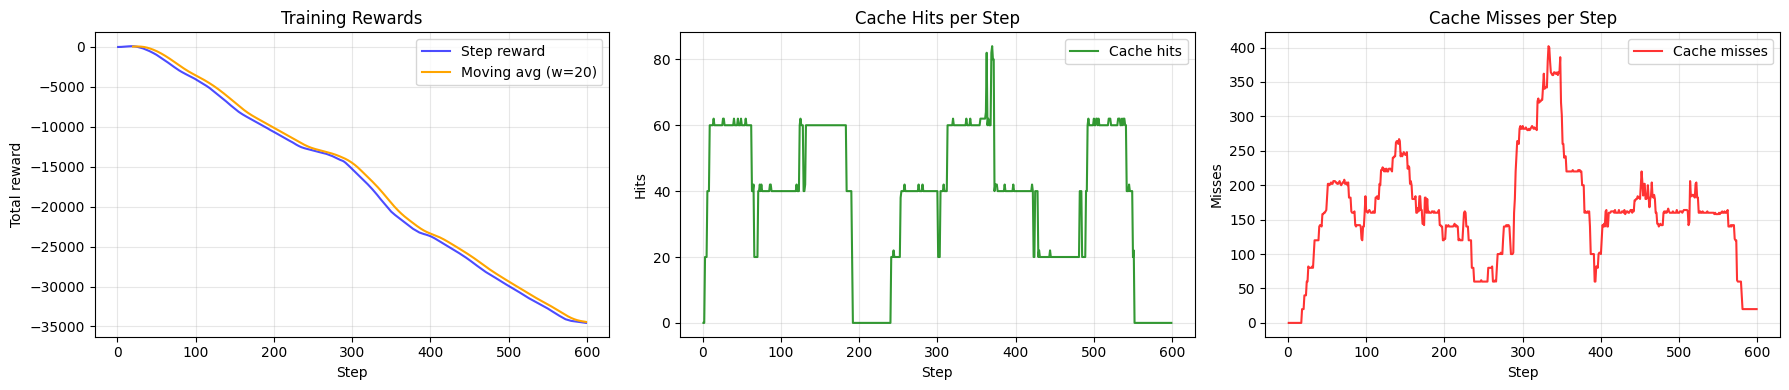

In [5]:
if __name__ == "__main__":
    # Combined plots: rewards (with moving average), cache hits, cache misses
    import matplotlib.pyplot as plt

    steps = range(1, len(results) + 1)
    cache_hits_series = [r["cache_hits"] for r in results]
    cache_misses_series = [r["cache_misses"] for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

    # Rewards with moving average
    axes[0].plot(steps, [r["total_reward"] for r in results], label="Step reward", alpha=0.7, color="blue")
    w = max(1, min(20, len(results) // 10))
    if w > 1:
        ma = [sum([r["total_reward"] for r in results][i - w:i]) / w for i in range(w, len(results) + 1)]
        axes[0].plot(range(w, len(results) + 1), ma, label=f"Moving avg (w={w})", color="orange")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Total reward")
    axes[0].set_title("Training Rewards")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Cache hits
    axes[1].plot(steps, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
    axes[1].set_title("Cache Hits per Step")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Hits")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Cache misses
    axes[2].plot(steps, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
    axes[2].set_title("Cache Misses per Step")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Misses")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()